In [1]:
"""
Automatically reloads libraries and utilities every time a cell is run
"""
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from utils.PSF_helpers import *
from utils.Plot_helpers import *
from utils.Zernike_helpers import *

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import factorial
from scipy.optimize import curve_fit
from scipy.ndimage import shift as ndi_shift

from scipy.io import loadmat

In [3]:
import imagej
ij = imagej.init(mode="headless")

def get_tif_file(path):
    data = ij.io().open(path)
    return ij.py.from_java(data).data

KeyboardInterrupt: 

In [11]:
#minor style things to make the figures look nice
plt.style.use("bmh")
plt.rcParams["figure.figsize"] = [548 / 72, 390 / 72]
plt.rcParams["font.size"] = 12
plt.rcParams['text.usetex'] = True
plt.rcParams["figure.dpi"] = 300
import os
os.environ["PATH"] += os.pathsep + "/Library/TeX/texbin"

In [5]:
N_order = 3                # 3 for 3P, 2 for 2P
lambd = 1.3e-3             # Wavelength [mm]
n = 1.333                  # Refractive index
k = 2*n*np.pi/lambd        # Wavenumber
num_apt = 1.05             # Numerical aperture
f = 7.2                    # Focal length of objective (Olympus) [mm]
grid_size = 128            # BFP resolution
L_bfp = 15.12              # BFP diameter [mm]
mag = 4                    # Magnification rate from input to objective
w_0 = 3.5                  # mm
num_apt = 1.05



In [6]:
r_pupil = f * num_apt
r_bfp = L_bfp / 2
na_eff = num_apt
#effective NA can be limited by the size of the back focal plane
if r_bfp < r_pupil:
    na_eff = r_bfp / f
alpha = np.arcsin(na_eff / n)

theta_grid_size = 64
R_BFP = r_bfp

microscope = Microscope(N_order, lambd, n, num_apt, f, mag, w_0, L_bfp, theta_grid_size)

In [7]:
exp_1 = "test_1_spherical_0.5"
exp_2 = "test_2_three_modes"
exp_3 = "test_3_spherical_collar"

mn_preset = [
    [-2, 2], [0, 2], [2, 2],
    [-3, 3], [-1, 3], [1, 3], [3, 3],
    [-4, 4], [-2, 4], [0, 4], [2, 4], [4, 4],
    [-5, 5], [-3, 5], [-1, 5], [1, 5], [3, 5], [5, 5],
    [-6, 6], [-4, 6], [-2, 6], [0, 6], [2, 6], [4, 6], [6, 6]
]

def read_experiment_log(exp_name):
    data = loadmat(f"4_22_booth_data/{exp_name}/booth_preset_log.mat")
    M_log = data["M0_log"].flatten()
    a_preset = data["aPreset"].flatten()
    correction_log = data["c_log"]
    return M_log, a_preset, correction_log

def plot_correction(M_log, a_preset, correction_log):
    ground_truth = M_log[0]
    M_log = M_log[1:]
    #normalization should have 1 quality at ground truth
    M_log = M_log / ground_truth
    fig, axs = plt.subplots(2, 1, figsize = (5, 5))
    axs[0].plot(M_log)
    axs[0].axhline(1, color = "tab:orange", label = "Ground Truth $M_0$", ls = "dashed")
    axs[1].set_xlabel("Iteration No.")
    axs[0].set_ylabel("Image Metric")
    axs[0].legend()

    z_orig = create_zernike_function(mn_preset, a_preset, alpha)
    indices = np.where(a_preset != 0)
    corrected_modes = np.zeros((len(correction_log), len(a_preset)))
    zmaps = []
    for i in range(len(corrected_modes)):
         corrected_modes[i][indices] = correction_log[i]
         zmaps.append(create_zernike_function(mn_preset, -1 * corrected_modes[i], alpha))

    errs = [zernike_RMS(z_orig, zmap, alpha) for zmap in zmaps]


         
    axs[1].plot(errs)
    axs[1].axhline(0, color = "tab:orange", label = "Ground Truth RMS", ls = "dashed")
    axs[1].set_ylabel("Correction RMS")
    axs[1].legend()
    


In [8]:
def plot_corrected_images(exp_name, filename):
    L_ffp = 0.0065
    grid_ffp = 512
    z_level = 0
    grid = Centered_Grid(L_ffp, grid_ffp, 0)
    x, y = grid.get_xy()

    M_log, a_preset, correction_log = read_experiment_log(exp_name)

    img = get_tif_file(f"4_22_booth_data/{exp_name}/Img_Booth_it1.tif")
    z_map = create_zernike_function(mn_preset, a_preset, alpha)
    composite_plot(x, y, img, z_map, alpha, filename + "_before")

    img = get_tif_file(f"4_22_booth_data/{exp_name}/Img_BoothPreset_Final.tif")
    a_correction = np.zeros_like(a_preset)
    a_correction[a_preset != 0 ] = correction_log[-1]
    z_map = create_zernike_function(mn_preset, a_preset + a_correction, alpha)
    composite_plot(x, y, img, z_map, alpha, filename + "_after")

    img = get_tif_file(f"4_22_booth_data/{exp_name}/Img_Booth_ground_truth.tif")
    z_map = create_zernike_function(mn_preset, np.zeros(len(mn_preset)), alpha)
    composite_plot(x, y, img, z_map, alpha, filename + "_ground_truth")

In [9]:
plot_corrected_images(exp_1, "exp_1")
plot_corrected_images(exp_2, "exp_2")

NameError: name 'get_tif_file' is not defined

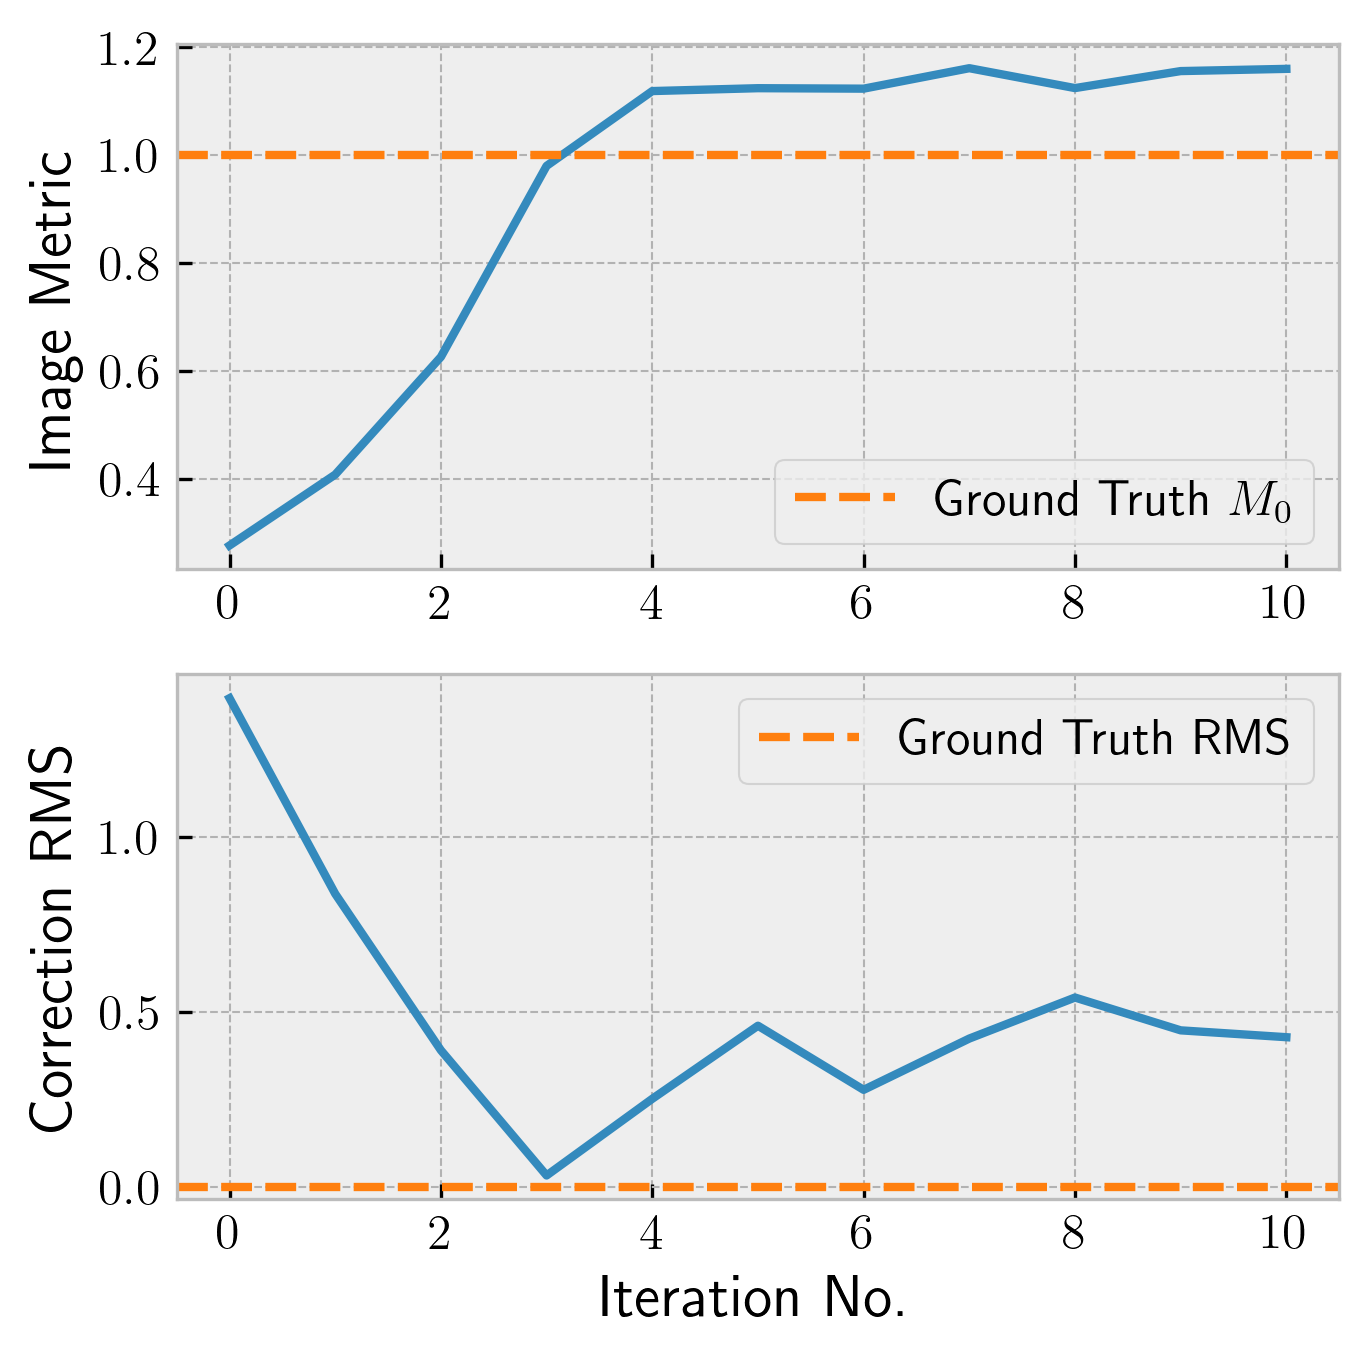

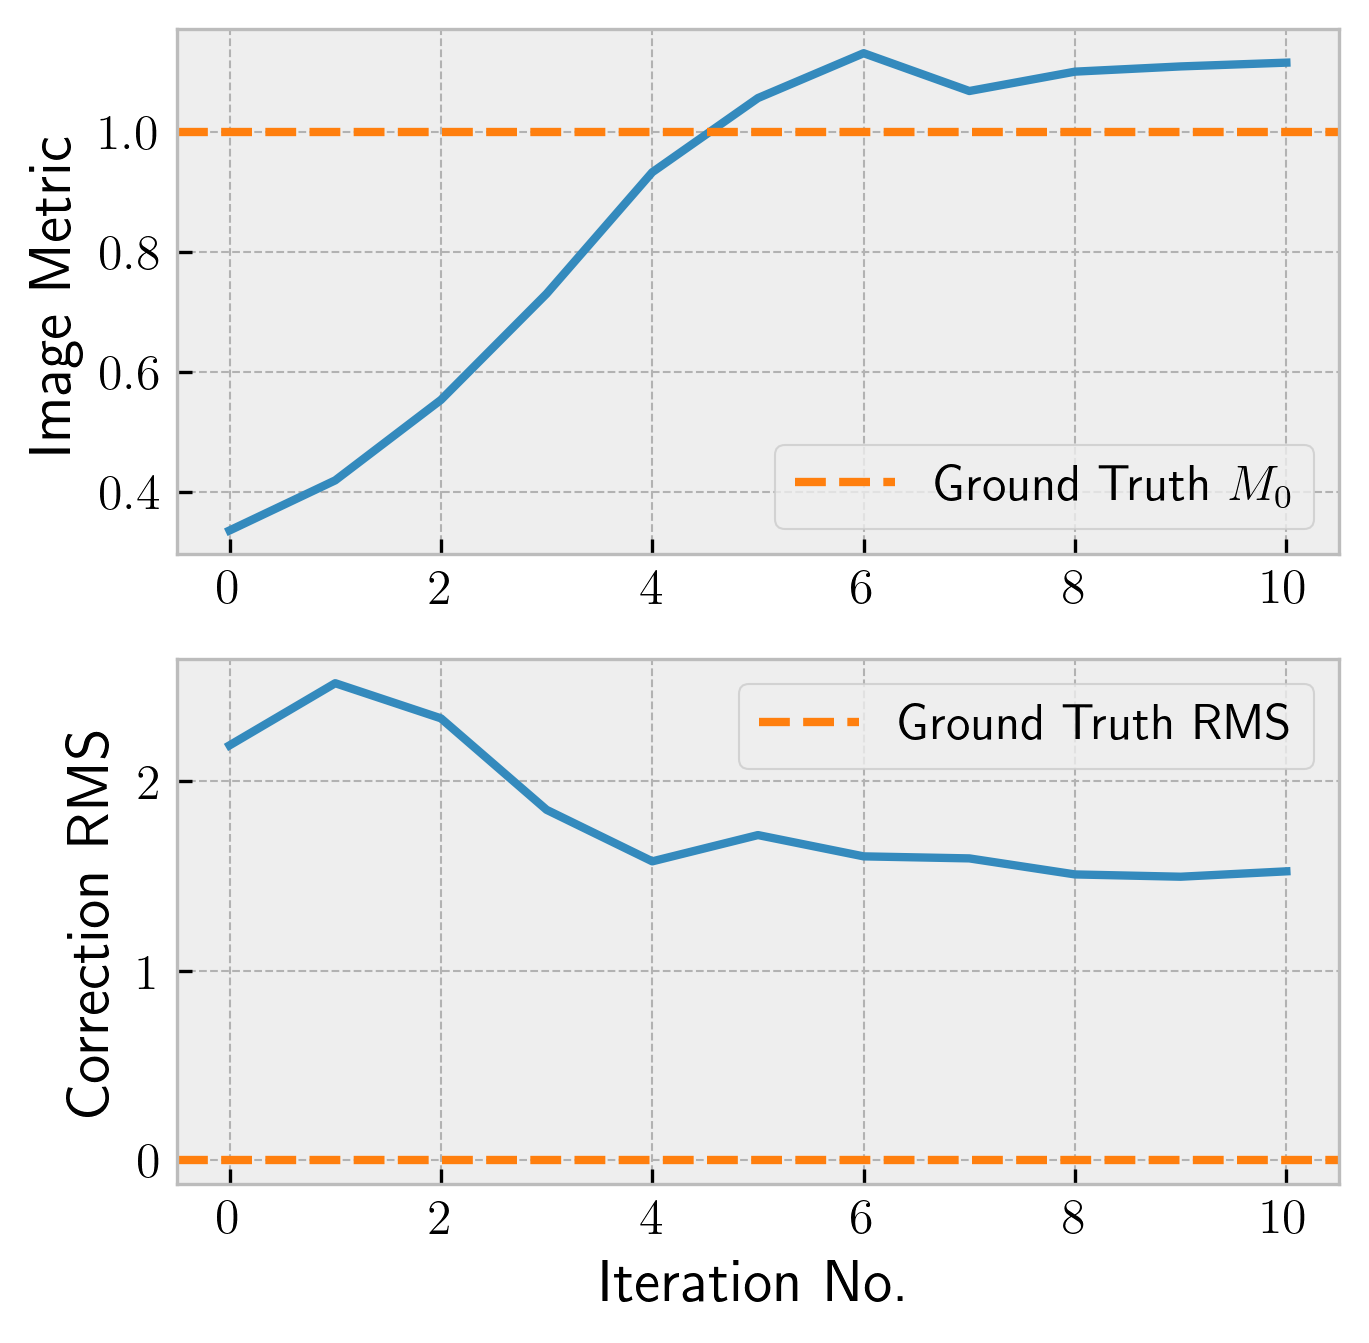

In [12]:
M_log, a_preset, correction_log = read_experiment_log(exp_1)
plot_correction(M_log, a_preset, correction_log)
plt.savefig("figures/correction_plot_exp_1.png")

M_log, a_preset, correction_log = read_experiment_log(exp_2)
plot_correction(M_log, a_preset, correction_log)
plt.savefig("figures/correction_plot_exp_2.png")